**IMPLEMENTING OPTIMIZERS BY HAND**

In [108]:
import torch
import matplotlib.pyplot as plt


In [109]:
number_of_classes = 5
number_of_features = 2
samples_per_class = 2004
centroids = torch.tensor([[3.0, 10], [4.5, -3], [8.09, 0], [-20,4], [0.01, 4]])

In [110]:
x_data = []
y_data = []
for class_id in range(number_of_classes):
  x = centroids[class_id] + 0.95 * torch.randn(samples_per_class, number_of_features)
  y = torch.full((samples_per_class,), class_id, dtype=torch.long)
  x_data.append(x)
  y_data.append(y)

x = torch.cat(x_data, dim=0)
y = torch.cat(y_data, dim=0)

In [111]:
perm = torch.randperm(x.shape[0])
x = x[perm]
y = y[perm]

In [112]:
x[0]

tensor([ 3.9734, 10.4894])

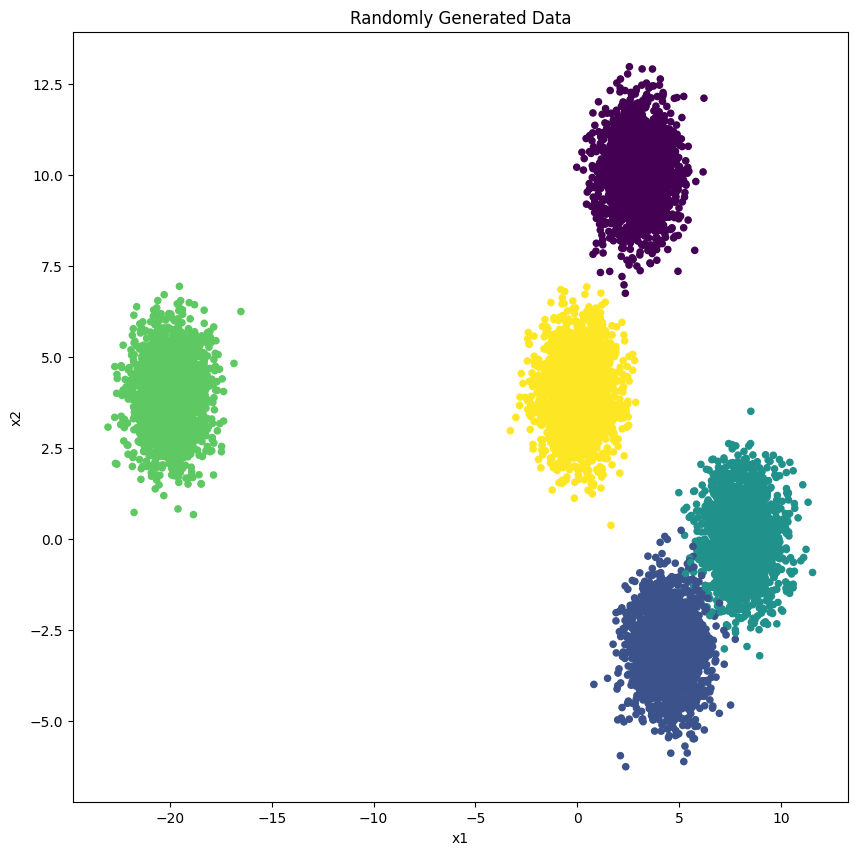

In [113]:
plt.figure(figsize=(10,10))
plt.scatter(x[:,0], x[:,1], c=y, s=20)
plt.title("Randomly Generated Data")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

In [114]:
class NeuralNetwork:
    def __init__(self, number_of_features, number_of_classes):
        self.in_dim = number_of_features
        self.out_dim = number_of_classes

        self.h1 = 10
        self.h2 = 10
        self.h3 = 5

        self.shapes = [
            (self.in_dim, self.h1),
            (self.h1, self.h2),
            (self.h2, self.h3),
            (self.h3, self.out_dim),
        ]

        self.params = {
            "w1" : torch.rand(self.shapes[0], requires_grad=False) * 0.05,
            "b1" : torch.zeros(self.shapes[0][1], requires_grad=False),
            "w2" : torch.rand(self.shapes[1], requires_grad=False) * 0.05,
            "b2" : torch.zeros(self.shapes[1][1], requires_grad=False),
            "w3" : torch.rand(self.shapes[2], requires_grad=False)* 0.05,
            "b3" : torch.zeros(self.shapes[2][1], requires_grad=False),
            "wO" : torch.rand(self.shapes[3], requires_grad=False) * 0.05,
            "bO" : torch.zeros(self.shapes[3][1], requires_grad=False),
        }

        self.gradients = {k: torch.zeros_like(v) for k, v in self.params.items()}
        self.cache = {}

    def __call__(self, x):
        self._forward(x)
        return self.cache["zO"]

    def _forward(self, x):
        self.cache["x"] = x
        self.cache["z1"] = x @ self.params["w1"] + self.params["b1"]
        self.cache["a1"] = self.cache["z1"].clamp(min=0)
        self.cache["z2"] = self.cache["a1"] @ self.params["w2"] + self.params["b2"]
        self.cache["a2"] = self.cache["z2"].clamp(min=0)
        self.cache["z3"] = self.cache["a2"] @ self.params["w3"] + self.params["b3"]
        self.cache["a3"] = self.cache["z3"].clamp(min=0)
        self.cache["zO"] = self.cache["a3"] @ self.params["wO"] + self.params["bO"]

    def backward(self, dlogits):

        # -- Gradients Output Layer --
        self.gradients["wO"] = self.cache["a3"].t() @ dlogits
        self.gradients["bO"] = dlogits.sum(axis=0)

        # -- Previous Layer Activation --
        self.gradients["a3"] = dlogits @ self.params["wO"].t()

        # -- ReLU Backward --
        self.gradients["z3"] = self.gradients["a3"] * (self.cache["z3"] > 0)

        # -- Gradients Third Hidden Layer --
        self.gradients["w3"] = self.cache["a2"].t() @ self.gradients["z3"]
        self.gradients["b3"] = self.gradients["z3"].sum(axis=0)

        # -- Previous Layer Activation --
        self.gradients["a2"] = self.gradients["z3"] @ self.params["w3"].t()

        # -- ReLU Backward --
        self.gradients["z2"] = self.gradients["a2"] * (self.cache["z2"] > 0)

        # -- Gradients Second Hidden Layer --
        self.gradients["w2"] = self.cache["a1"].t() @ self.gradients["z2"]
        self.gradients["b2"] = self.gradients["z2"].sum(axis=0)

        # -- Previous Layer Activation --
        self.gradients["a1"] = self.gradients["z2"] @ self.params["w2"].t()

        # -- ReLU Backward --
        self.gradients["z1"] = self.gradients["a1"] * (self.cache["z1"] > 0)

        # -- Gradients First Hidden Layer
        self.gradients["w1"] = self.cache["x"].t() @ self.gradients["z1"]
        self.gradients["b1"] = self.gradients["z1"].sum(axis=0)

    def zero_grads(self):
      self.gradients = {k: torch.zeros_like(v) for k, v in self.params.items()}


In [140]:
def cross_entropy_loss(logits, labels, eps=1e-12):

    z = logits - logits.max(axis=1, keepdim=True).values
    z_exp = torch.exp(z)
    probs = z_exp / z_exp.sum(axis=1, keepdim=True)

    N = probs.shape[0]

    if labels.dim() == 1:
      correct_probs = probs[torch.arange(N), labels]
      loss = -torch.log(correct_probs.clamp(min=eps)).mean()

      dlogits = probs.clone()
      dlogits[torch.arange(N), labels] -= 1
      dlogits /= N

    else:
      loss = -(labels * torch.log(probs.clamp(min=eps))).sum(dim=1).mean()
      dlogits = (probs - labels) / N

    return loss, dlogits

$$
\theta_t = \theta_{t-1} - \eta g_t
$$

where

$$
g_t = \nabla L(\theta_{t-1})
$$

In [141]:
models = {"SGD": NeuralNetwork(number_of_features, number_of_classes),"Momentum": NeuralNetwork(number_of_features, number_of_classes),
          "Adam": NeuralNetwork(number_of_features, number_of_classes), "Nesterov" : NeuralNetwork(number_of_features, number_of_classes),
          "RMSProp" : NeuralNetwork(number_of_features, number_of_classes)}

In [142]:
class MomentumOptimizer():
  def __init__(self, model, learning_rate=1e-2, momentum=0.9):
    self.model = model
    self.learning_rate = learning_rate
    self.momentum = momentum
    self.velocity = {k: torch.zeros_like(v) for k,v in self.model.params.items()}

  def step(self):
    for k in self.model.params:
      self.velocity[k] = self.momentum * self.velocity[k] + self.model.gradients[k]
      self.model.params[k] = self.model.params[k] - self.learning_rate * self.velocity[k]



In [143]:
class AdamOptimizer():
  def __init__(self, model, learning_rate=1e-2, beta1=0.9, beta2 = 0.999, eps=1e-8):
    self.t = 1
    self.model = model
    self.learning_rate = learning_rate
    self.beta1 = beta1
    self.beta2 = beta2
    self.eps = eps
    self.m = {k:torch.zeros_like(v) for k,v in self.model.params.items()}
    self.v = {k:torch.zeros_like(v) for k,v in self.model.params.items()}

  def step(self):
    for k in self.model.params:
      self.m[k] = self.beta1 * self.m[k] + (1-self.beta1) * self.model.gradients[k]
      self.v[k] = self.beta2 * self.v[k] + (1-self.beta2) * self.model.gradients[k]**2

      m_hat = self.m[k] / (1-self.beta1 ** self.t)
      v_hat = self.v[k] / (1-self.beta2 ** self.t)

      self.model.params[k] = self.model.params[k] - self.learning_rate * m_hat / (torch.sqrt(v_hat) + self.eps)

    self.t += 1


In [144]:
class NesterovMomentumOptimizer():
  def __init__(self, model, learning_rate=1e-2, momentum=0.9):
    self.model = model
    self.learning_rate = learning_rate
    self.momentum = momentum
    self.velocity = {k: torch.zeros_like(v) for k,v in self.model.params.items()}

  def step(self):
    for k in self.model.params:
      self.velocity[k] = self.momentum * self.velocity[k] + self.model.gradients[k]
      self.model.params[k] = self.model.params[k] - self.learning_rate * (self.model.gradients[k] + self.momentum * self.velocity[k])

In [145]:
class RMSPropOptimizer():
  def __init__(self, model, learning_rate=1e-2, beta=0.9, eps = 1e-8):
    self.model = model
    self.learning_rate = learning_rate
    self.beta = beta
    self.velocity = {k: torch.zeros_like(v) for k,v in self.model.params.items()}
    self.eps = eps

  def step(self):
    for k in self.model.params:
      self.velocity[k] = self.beta * self.velocity[k] + (1 - self.beta) * self.model.gradients[k]**2
      self.model.params[k] = self.model.params[k] - self.learning_rate * self.model.gradients[k] / (torch.sqrt(self.velocity[k] + self.eps))

In [146]:
optimizers = {
    "SGD" : None,
    "Momentum" : MomentumOptimizer(models["Momentum"]),
    "Adam" : AdamOptimizer(models["Adam"]),
    "Nesterov": NesterovMomentumOptimizer(models["Nesterov"]),
    "RMSProp" : RMSPropOptimizer(models["RMSProp"])
}

In [147]:
loss_storage = {
    "epoch" : {"SGD":[], "Momentum":[], "Adam":[], "Nesterov":[], "RMSProp" : []},
    "step"  : {"SGD":[], "Momentum":[], "Adam":[], "Nesterov":[], "RMSProp" : []}
}

In [148]:
norm_storage = {
    "grad" : {"SGD":[], "Momentum":[], "Adam":[], "Nesterov":[], "RMSProp" : []},
    "param"  : {"SGD":[], "Momentum":[], "Adam":[], "Nesterov":[], "RMSProp" : []}
}

In [149]:
def train(optimization_strat = "SGD", input=x, labels=y, batch_size=32, epochs=100, learning_rate=1e-2, loss_fn=cross_entropy_loss):

    model = models[optimization_strat]
    optimizer = optimizers[optimization_strat]

    N = input.shape[0]

    for epoch in range(epochs):

        # --- Shuffle entire dataset once per epoch ---
        perm = torch.randperm(N)
        x = input[perm]
        y = labels[perm]

        # --- Collect loss over entire epoch
        # --- Collect number of samples seen

        loss_sum = 0.0
        n_seen = 0


        for batch in range(0, N, batch_size):

            model.zero_grads()

            x_batch = x[batch:batch+batch_size]
            y_batch = y[batch:batch+batch_size]

            logits = model(x_batch)
            loss, dlogits = loss_fn(logits, y_batch)


              # --- Extract how many samples on batch ---
            batch_n = x_batch.shape[0]
              # --- Multiply loss by samples in batch because loss gets averaged over the batch
            loss_sum += loss.item() * batch_n
              # --- Add the number of examples in the batch to the running total
            n_seen += batch_n

            model.backward(dlogits)

            grad_sq_sum = 0.0
            for k in model.params:
              grad_sq_sum += torch.sum(model.gradients[k] ** 2)
            grad_norm = torch.sqrt(grad_sq_sum)
            norm_storage["grad"][optimization_strat].append(grad_norm.item())

            # --- Manual SGD ---
            if optimizer is None:
                with torch.no_grad():
                    for k in model.params:
                        model.params[k] -= learning_rate * model.gradients[k]
            else:
                optimizer.step()

            param_sq_sum = 0.0
            for k in model.params:
              param_sq_sum += torch.sum(model.params[k] ** 2)
            param_norm = torch.sqrt(param_sq_sum)
            norm_storage["param"][optimization_strat].append(param_norm.item())

            loss_storage["step"][optimization_strat].append(loss.item())
        # --- Compute avg loss per epoch
        avg_epoch_loss = loss_sum / n_seen


        loss_storage["epoch"][optimization_strat].append(avg_epoch_loss)


        if epoch % 10 == 0:

          print(f"Epoch {epoch}: Avg Loss = {avg_epoch_loss:.6f}")

In [174]:
train("Nesterov")

Epoch 0: Avg Loss = 1.570649
Epoch 10: Avg Loss = 0.027618
Epoch 20: Avg Loss = 0.012354
Epoch 30: Avg Loss = 0.010433
Epoch 40: Avg Loss = 0.010386
Epoch 50: Avg Loss = 0.009200
Epoch 60: Avg Loss = 0.009158
Epoch 70: Avg Loss = 0.010348
Epoch 80: Avg Loss = 0.007566
Epoch 90: Avg Loss = 0.007562


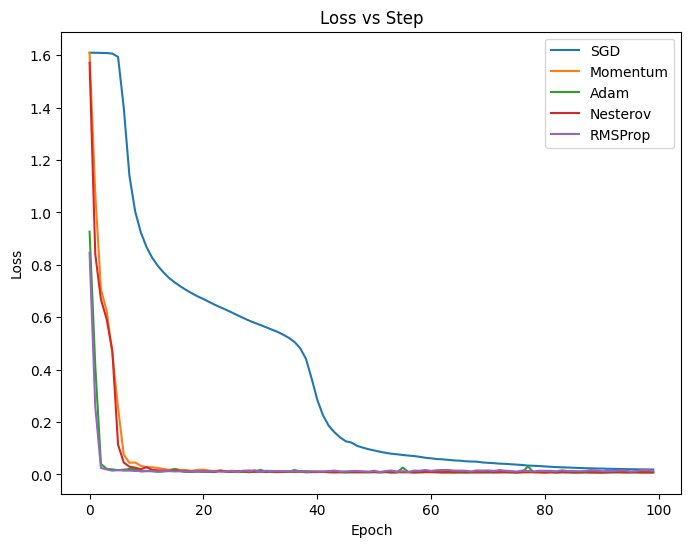

In [175]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.plot(loss_storage['epoch']["SGD"])
plt.plot(loss_storage['epoch']["Momentum"])
plt.plot(loss_storage['epoch']["Adam"])
plt.plot(loss_storage['epoch']["Nesterov"])
plt.plot(loss_storage['epoch']["RMSProp"])
plt.title("Loss vs Step")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["SGD", "Momentum", "Adam", "Nesterov", "RMSProp"])
plt.show()

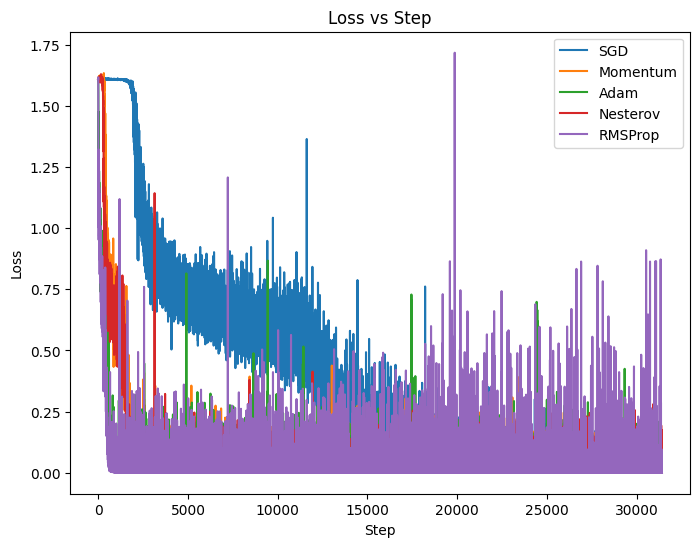

In [176]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.plot(loss_storage['step']["SGD"])
plt.plot(loss_storage['step']["Momentum"])
plt.plot(loss_storage['step']["Adam"])
plt.plot(loss_storage['step']["Nesterov"])
plt.plot(loss_storage['step']["RMSProp"])
plt.title("Loss vs Step")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.legend(["SGD", "Momentum", "Adam", "Nesterov", "RMSProp"])
plt.show()

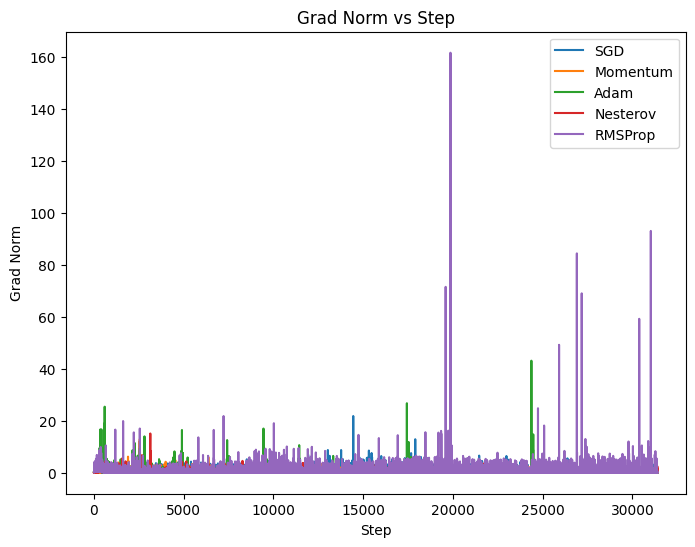

In [179]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.plot(norm_storage['grad']["SGD"])
plt.plot(norm_storage['grad']["Momentum"])
plt.plot(norm_storage['grad']["Adam"])
plt.plot(norm_storage['grad']["Nesterov"])
plt.plot(norm_storage['grad']["RMSProp"])
plt.title("Grad Norm vs Step")
plt.xlabel("Step")
plt.ylabel("Grad Norm")
plt.legend(["SGD", "Momentum", "Adam", "Nesterov", "RMSProp"])
plt.show()

In [ ]:
θ_t

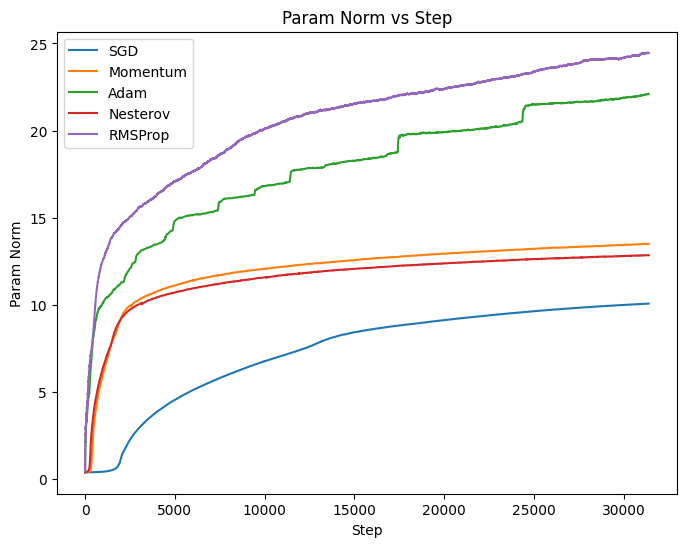

In [181]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.plot(norm_storage['param']["SGD"])
plt.plot(norm_storage['param']["Momentum"])
plt.plot(norm_storage['param']["Adam"])
plt.plot(norm_storage['param']["Nesterov"])
plt.plot(norm_storage['param']["RMSProp"])
plt.title("Param Norm vs Step")
plt.xlabel("Step")
plt.ylabel("Param Norm")
plt.legend(["SGD", "Momentum", "Adam", "Nesterov", "RMSProp"])
plt.show()